Hello there. this is the time series forecasting notebook for our ev charging queues. our primary objective here is to predict the wait time at our municipal charging hubs for the immediate next hour.

before you start hammering the run button, make sure you actually downloaded the telemetry dataset to your local machine. go through the blocks sequentially. i have laid out the base architecture, but there are a few subtle architectural flaws and data leaks intentionally seeded in the pipeline. your job is to find them, fix them, and build out the custom feature engineering block i left for you.

In [ ]:
import numpy as np
import pandas as pd
import io
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# prompt to upload the municipal telemetry csv file
uploaded = files.upload()
filename = list(uploaded.keys())[0]
data = pd.read_csv(io.BytesIO(uploaded[filename]))

print("dataset loaded successfully")
print("columns:", data.shape[1])
print("rows:", data.shape[0])
data.head()

here is where we translate raw timestamps into math. a gradient boosting model does not know what a tuesday is, so we have to map cyclical time using sine and cosine waves.

i also added some hard binary flags for time-based features: `is_weekend` and `is_peak_hour`. these give the model a massive mathematical shortcut to recognize high-traffic commuter windows without guessing.

In [ ]:
# sort chronologically so our time series flows in the correct direction
data['date_time'] = pd.to_datetime(data['date_time'])
data = data.sort_values('date_time').reset_index(drop=True)

# cyclical time encoding
data['hour_sin'] = np.sin(2 * np.pi * data['date_time'].dt.hour / 12.0)
data['hour_cos'] = np.cos(2 * np.pi * data['date_time'].dt.hour / 12.0)

# time based classification features
data['is_weekend'] = data['date_time'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

peak_hours = [8, 9, 17, 18, 19]
data['is_peak_hour'] = data['date_time'].dt.hour.apply(lambda x: 1 if x in peak_hours else 0)

# trailing averages to smooth out sudden spikes
data['grid_trend_3h'] = data['grid_load_mw'].rolling(window=3).mean()
data['traffic_trend_3h'] = data['vehicles_charged'].rolling(window=3).mean()

now it is your turn to build. the model needs more granularity. 

use my code above as a reference and write your own features in the block below. we specifically need to capture night shifts (when the grid is at its absolute lowest capacity) and we need a wider rolling average for the traffic data.

In [ ]:
def engineer_custom_time_features(df):
    # your task 1: create an 'is_night_time' feature.
    # mark it as 1 if the hour is between 11 pm (23) and 5 am (5), otherwise 0.
    
    # your code here
    
    
    # your task 2: create a rolling 6-hour average for 'vehicles_charged'.
    # name the new column 'traffic_rolling_6h_avg'. 
    # hint: use the pandas rolling() and mean() functions just like i did above.
    
    # your code here
    
    return df

data = engineer_custom_time_features(data)

we need to clean up missing values and scale the data so large megawatt numbers do not overpower the small categorical flags during gradient descent. keep an eye on how missing values are handled here. time series data is very sensitive to how you fill gaps.

In [ ]:
from sklearn.preprocessing import StandardScaler

# handle missing values generated by our rolling averages
data.fillna(method='bfill', inplace=True)

# one hot encode categorical strings
data = pd.get_dummies(data, columns=['station_type', 'peak_load_risk'], drop_first=True)

# drop text columns that the model cannot process
features = data.drop(columns=['date_time', 'record_id', 'city_zone'])

# z-score normalization
scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(features)
scaled_df = pd.DataFrame(scaled_matrix, columns=features.columns)

target_idx = features.columns.get_loc('avg_charging_duration_minutes')
data_matrix = scaled_df.values

this is where we slice the dataset into fixed observation blocks. our regressor cannot read sequential data natively, so we take the last 12 hours of data, flatten it into a single wide row, and map it to a target prediction.

watch the index math carefully here. it is incredibly easy to accidentally predict the present moment instead of forecasting the future.

In [ ]:
def create_sliding_windows(data_matrix, target_idx, window_size=12):
    X, y = [], []
    for i in range(len(data_matrix) - window_size):
        block = data_matrix[i : i + window_size, :]
        
        # grab the target label at the end of the window
        label = data_matrix[i + window_size - 1, target_idx]
        
        X.append(block.flatten())
        y.append(label)
        
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y = create_sliding_windows(data_matrix, target_idx, window_size=12)

now we partition our sequences into training and validation sets. once split, we fit the gradient boosting regressor. think critically about how time series data should be split before you assume the standard configuration is correct.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor

# split the arrays into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train the gradient boosting regressor
model = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
model.fit(X_train, y_train)
preds = model.predict(X_test)

finally, we calculate our error metrics to see how well the model is performing. verify that the calculations actually align with the printed labels.

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# calculate the core metrics
mae = mean_absolute_error(y_test, preds)
mse = mean_squared_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("pipeline evaluation results")
print("mean absolute error:", mae)
print("root mean squared error:", mse)
print("r-squared index:", r2)

a standard scatter plot comparing the actual test targets against our predicted targets allows us to visually inspect the model accuracy. write a quick script below to plot `y_test` against `preds`.

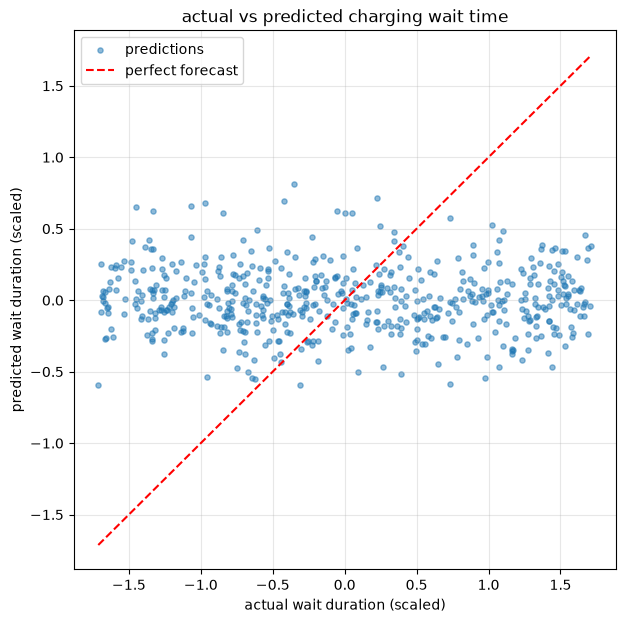

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(y_test, preds, s=14, alpha=0.5, color='tab:blue', label='predictions')

# 45 degree line, a perfect forecaster would put every point on it
low = min(y_test.min(), preds.min())
high = max(y_test.max(), preds.max())
plt.plot([low, high], [low, high], 'r--', linewidth=1.5, label='perfect forecast')

plt.xlabel('actual wait duration (scaled)')
plt.ylabel('predicted wait duration (scaled)')
plt.title('actual vs predicted charging wait time')
plt.legend()
plt.grid(alpha=0.3)
plt.show()